In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

In [2]:
# Import the data
test_df = pd.read_csv(r'data\Corona_NLP_test.csv',encoding='ISO-8859-1')
train_df = pd.read_csv(r'data\Corona_NLP_train.csv',encoding='ISO-8859-1')

In [3]:
# We need to see the whole text on the dataframe that 's why we need to display.max_colwidth
pd.set_option('display.max_colwidth', None)

In [4]:
train_df.head()

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3799,48751,London,16-03-2020,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/iFz9FAn2Pa and https://t.co/xX6ghGFzCC and https://t.co/I2NlzdxNo8,Neutral
1,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to exchange phone numbers create contact list with phone numbers of neighbours schools employer chemist GP set up online shopping accounts if poss adequate supplies of regular meds but not over order,Positive
2,3801,48753,Vagabonds,16-03-2020,"Coronavirus Australia: Woolworths to give elderly, disabled dedicated shopping hours amid COVID-19 outbreak https://t.co/bInCA9Vp8P",Positive
3,3802,48754,NaN,16-03-2020,"My food stock is not the only one which is empty...\r\r\n\r\r\nPLEASE, don't panic, THERE WILL BE ENOUGH FOOD FOR EVERYONE if you do not take more than you need. \r\r\nStay calm, stay safe.\r\r\n\r\r\n#COVID19france #COVID_19 #COVID19 #coronavirus #confinement #Confinementotal #ConfinementGeneral https://t.co/zrlG0Z520j",Positive
4,3803,48755,NaN,16-03-2020,"Me, ready to go at supermarket during the #COVID19 outbreak.\r\r\n\r\r\nNot because I'm paranoid, but because my food stock is litteraly empty. The #coronavirus is a serious thing, but please, don't panic. It causes shortage...\r\r\n\r\r\n#CoronavirusFrance #restezchezvous #StayAtHome #confinement https://t.co/usmuaLq72n",Extremely Negative


In [5]:
train_df.shape

(41157, 6)

In [6]:
train_df.describe()

,UserName,ScreenName
count,41157.000000,41157.000000
mean,24377.000000,69329.000000
std,11881.146851,11881.146851
min,3799.000000,48751.000000
25%,14088.000000,59040.000000
50%,24377.000000,69329.000000
75%,34666.000000,79618.000000
max,44955.000000,89907.000000


In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41157 entries, 0 to 41156
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   UserName       41157 non-null  int64 
 1   ScreenName     41157 non-null  int64 
 2   Location       32567 non-null  object
 3   TweetAt        41157 non-null  object
 4   OriginalTweet  41157 non-null  object
 5   Sentiment      41157 non-null  object
dtypes: int64(2), object(4)
memory usage: 1.9+ MB


# EDA

Training Set

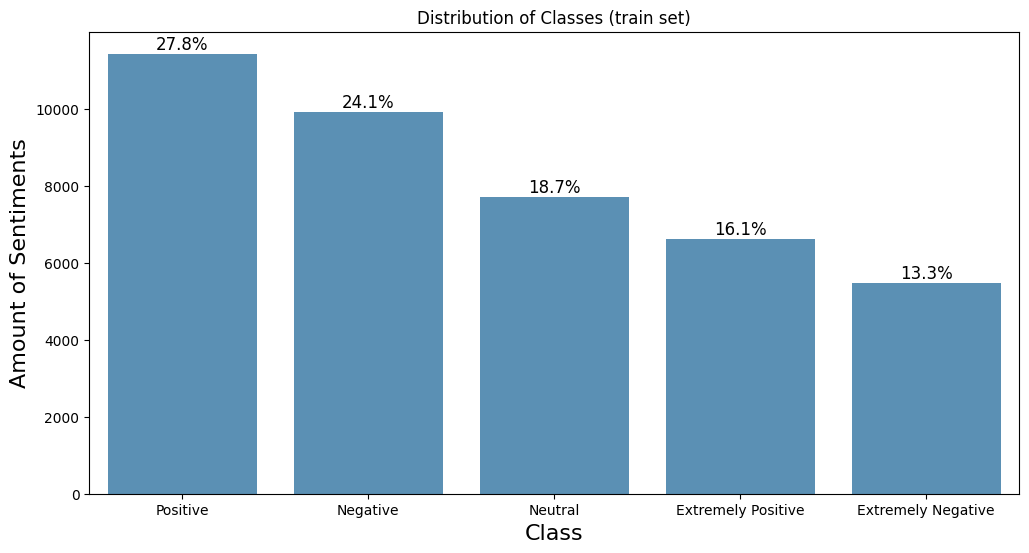

In [8]:
# Plot the Labels distribution
plt.figure(figsize=(12,6))
label_counts = train_df['Sentiment'].value_counts().reset_index()
label_counts.columns = ['Sentiment', 'Count']
# Calculate percentages
total = label_counts['Count'].sum()
label_counts['Percentage'] = 100 * label_counts['Count'] / total

ax = sns.barplot(data=label_counts,x='Sentiment',y='Count',alpha=0.8)

plt.ylabel('Amount of Sentiments', fontsize=16)
plt.xlabel('Class', fontsize=16)
plt.title('Distribution of Classes (train set)')
# Add percentage labels on bars
for i, row in label_counts.iterrows():
    ax.text(
        i,
        row['Count'],
        f"{row['Percentage']:.1f}%",
        ha='center',
        va='bottom',
        fontsize=12
    )

plt.show()

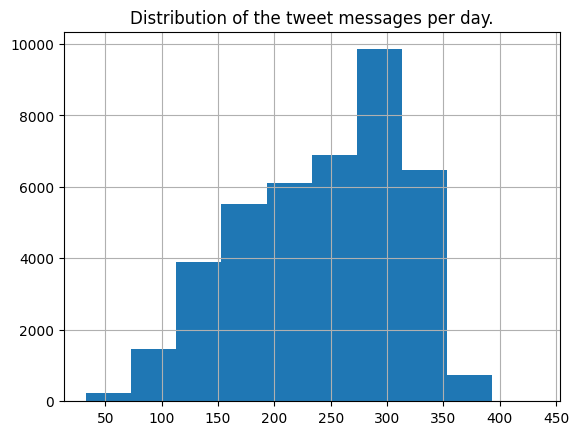

In [9]:
# Let 's calculate the histogram of the length of the headlines
train_df['OriginalTweet'] = train_df[train_df.columns[2:]].apply(lambda x: '. '.join(x.dropna().astype(str)),axis=1)
train_df['OriginalTweet_length'] = train_df['OriginalTweet'].apply(lambda x : len(x))
train_df['OriginalTweet_length'].hist()
plt.title('Distribution of the tweet messages per day.')

# Drop the comment lenght column. After the plot we don 't need it.
train_df.drop(columns=['OriginalTweet_length'], inplace=True)

In [10]:
# Check for null values
train_df.isnull().sum()

UserName            0
ScreenName          0
Location         8590
TweetAt             0
OriginalTweet       0
Sentiment           0
dtype: int64

In [11]:
train_df.dropna(inplace = True)

Location has 22% of null data.

In [12]:
# Check for duplicates records
train_df.duplicated().sum()

np.int64(0)

Testing Set

In [13]:
test_df.head()

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,1,44953,NYC,02-03-2020,"TRENDING: New Yorkers encounter empty supermarket shelves (pictured, Wegmans in Brooklyn), sold-out online grocers (FoodKick, MaxDelivery) as #coronavirus-fearing shoppers stock up https://t.co/Gr76pcrLWh https://t.co/ivMKMsqdT1",Extremely Negative
1,2,44954,"Seattle, WA",02-03-2020,"When I couldn't find hand sanitizer at Fred Meyer, I turned to #Amazon. But $114.97 for a 2 pack of Purell??!!Check out how #coronavirus concerns are driving up prices. https://t.co/ygbipBflMY",Positive
2,3,44955,NaN,02-03-2020,Find out how you can protect yourself and loved ones from #coronavirus. ?,Extremely Positive
3,4,44956,Chicagoland,02-03-2020,#Panic buying hits #NewYork City as anxious shoppers stock up on food&amp;medical supplies after #healthcare worker in her 30s becomes #BigApple 1st confirmed #coronavirus patient OR a #Bloomberg staged event?\r\r\n\r\r\nhttps://t.co/IASiReGPC4\r\r\n\r\r\n#QAnon #QAnon2018 #QAnon2020 \r\r\n#Election2020 #CDC https://t.co/29isZOewxu,Negative
4,5,44957,"Melbourne, Victoria",03-03-2020,#toiletpaper #dunnypaper #coronavirus #coronavirusaustralia #CoronaVirusUpdate #Covid_19 #9News #Corvid19 #7NewsMelb #dunnypapergate #Costco One week everyone buying baby milk powder the next everyone buying up toilet paper. https://t.co/ScZryVvsIh,Neutral


In [14]:
test_df.shape

(3798, 6)

In [15]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3798 entries, 0 to 3797
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   UserName       3798 non-null   int64 
 1   ScreenName     3798 non-null   int64 
 2   Location       2964 non-null   object
 3   TweetAt        3798 non-null   object
 4   OriginalTweet  3798 non-null   object
 5   Sentiment      3798 non-null   object
dtypes: int64(2), object(4)
memory usage: 178.2+ KB


In [16]:
test_df.describe()

,UserName,ScreenName
count,3798.000000,3798.000000
mean,1899.500000,46851.500000
std,1096.532489,1096.532489
min,1.000000,44953.000000
25%,950.250000,45902.250000
50%,1899.500000,46851.500000
75%,2848.750000,47800.750000
max,3798.000000,48750.000000


In [17]:
test_df.isnull().sum()

UserName           0
ScreenName         0
Location         834
TweetAt            0
OriginalTweet      0
Sentiment          0
dtype: int64

In [18]:
# Drop the null values
test_df = test_df.dropna()

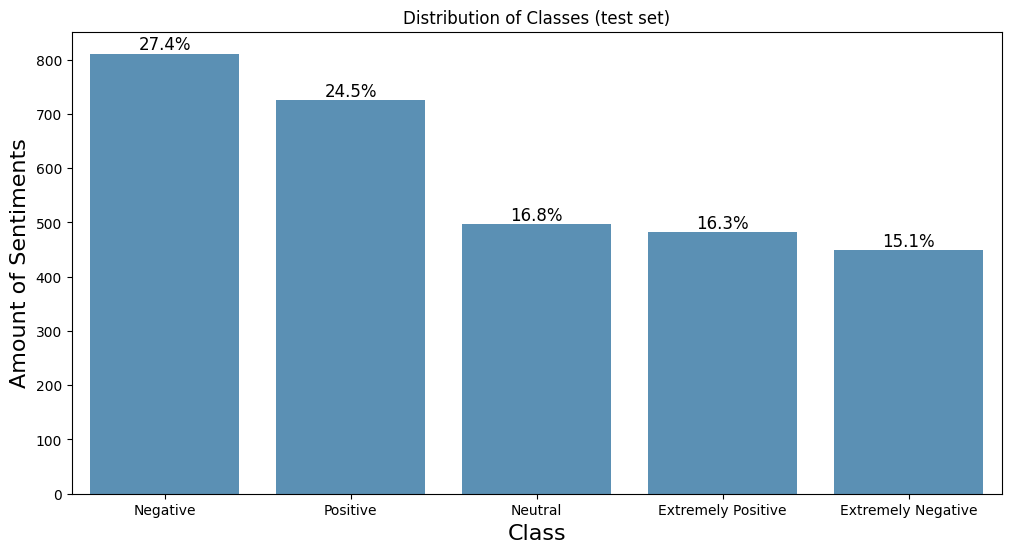

In [19]:
# Plot the Labels distribution
plt.figure(figsize=(12,6))
label_counts = test_df['Sentiment'].value_counts().reset_index()
label_counts.columns = ['Sentiment', 'Count']
# Calculate percentages
total = label_counts['Count'].sum()
label_counts['Percentage'] = 100 * label_counts['Count'] / total

ax = sns.barplot(data=label_counts,x='Sentiment',y='Count',alpha=0.8)

plt.ylabel('Amount of Sentiments', fontsize=16)
plt.xlabel('Class', fontsize=16)
plt.title('Distribution of Classes (test set)')
# Add percentage labels on bars
for i, row in label_counts.iterrows():
    ax.text(
        i,
        row['Count'],
        f"{row['Percentage']:.1f}%",
        ha='center',
        va='bottom',
        fontsize=12
    )

plt.show()

# Preprocess
Steps that we need to follow:<br>

a) Lowercasing the data.<br>

b) Remove Puntuations.<br>

c) Remove stopwords. Why we need to remove stopwords?<br>
Stop words are only for sentence formation but in the meaning of the sentence, stop words are not important. Examples of stopwords are 'the', 'is', 'and' etc.<br>

d) Remove URL 's 

d) Remove emojis, HTML Tags , ChatWords. It is really unexpected to get emojis and ChatWords on reddit headings but we should implement a function to be ensure accurate analysis <br>and text understanding.

e) Tokenization is a crucial step in NLP text preprocessing where text is segmented into smaller units, typically words or subwords, known as tokens. This process is essential <br>for several reasons. Firstly, it breaks down the text into manageable units for analysis and processing. Secondly, it standardizes the representation of words, enabling <br>consistency in language modeling tasks. Additionally, tokenization forms the basis for feature extraction and modeling in NLP, facilitating tasks such as sentiment analysis, <br>named entity recognition, and machine translation.<br>

d) Apply Lemmatization instead of Stemming as in that way we can use deep learning / embeddings (Word2Vec, BERT).Lemmatization reduce words to their base or dictionary form <br>(lemma), enhancing consistency and simplifying analysis.

In [20]:
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk import pos_tag
import re, string

# Define which stopwords to remove 
stopwords_list = stopwords.words('english')
translator = str.maketrans('', '', string.punctuation) # remove punctuations

# remove the emoji 's
emoji_pattern = re.compile("[" 
                           u"\U0001F600-\U0001F64F"
                           u"\U0001F300-\U0001F5FF"
                           u"\U0001F680-\U0001F6FF"
                           u"\U0001F1E0-\U0001F1FF"
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)

# create a word lemmatizer object
lemmatizer = WordNetLemmatizer()

# we create a function pos (part of speech) since the lemmatizer needs to now 
# each and every word what type of part of speech is (noun, verb, etc...)
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN
    
def remove_urls(text):
    pattern = re.compile(r'https?://\S+|www\.\S+')
    return pattern.sub(r'', text)

def process_text(text):
    if not isinstance(text, str):
        return ''
    text = remove_urls(text)
    text = text.lower()
    text = text.translate(translator)
    text = emoji_pattern.sub('', text)
    text = re.sub('<.*?>', '', text)
    text = re.sub(r'\d+','',text) # with that regex clean the unecessary random numbers inside the tokens
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stopwords_list]
    # Lemmatize
    pos_tags = pos_tag(tokens)
    tokens = [lemmatizer.lemmatize(word, get_wordnet_pos(pos)) for word, pos in pos_tags]
    # Return cleaned text as STRING
    return " ".join(tokens)
def clean_data(dataset):
    data = dataset.copy()
    if 'OriginalTweet' not in data.columns:
        raise ValueError("Column 'OriginalTweet' not found")

    data['OriginalTweet'] = data['OriginalTweet'].apply(process_text)
    return data

clean_data(train_df)

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3799,48751,London,16-03-2020,london menyrbie philgahan chrisitv neutral,Neutral
1,3800,48752,UK,16-03-2020,uk advice talk neighbour family exchange phone number create contact list phone number neighbour school employer chemist gp set online shop account poss adequate supply regular med order positive,Positive
2,3801,48753,Vagabonds,16-03-2020,vagabond coronavirus australia woolworth give elderly disable dedicate shopping hour amid covid outbreak positive,Positive
5,3804,48756,"ÃT: 36.319708,-82.363649",16-03-2020,ãt news regionâs first confirm covid case come sullivan county last week people flock area store purchase clean supply hand sanitizer food toilet paper good timdodson report positive,Positive
6,3805,48757,"35.926541,-78.753267",16-03-2020,cashier grocery store share insight covid prove credibility comment im civics class know im talk positive,Positive
...,...,...,...,...,...,...
41147,44946,89898,"Brooklyn, NY",14-04-2020,brooklyn ny yâall really shit much home covid coronavirus toiletpaper negative,Negative
41149,44948,89900,"Toronto, Ontario",14-04-2020,toronto ontario still shock number toronto supermarket employee work without sort mask know employee asymptomatic spread coronavirus negative,Negative
41150,44949,89901,OHIO,14-04-2020,ohio never weâd situation amp world go supermarket pick package mail like play russian roulette life coronavirus stayhome socialdistancing positive,Positive
41152,44951,89903,"Wellington City, New Zealand",14-04-2020,wellington city new zealand airline pilot offer stock supermarket shelf nz lockdown covid neutral,Neutral


Visualize the most common unigramms and bigramms for both training and testing subset.

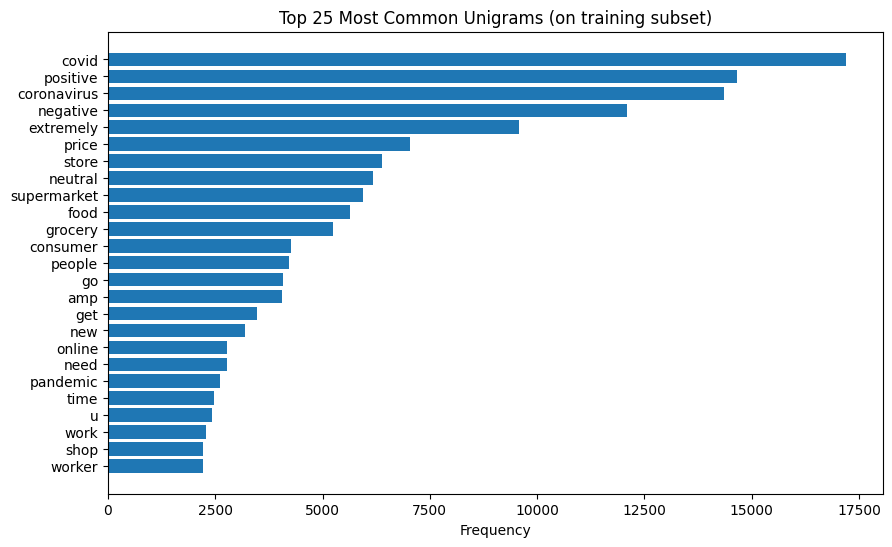

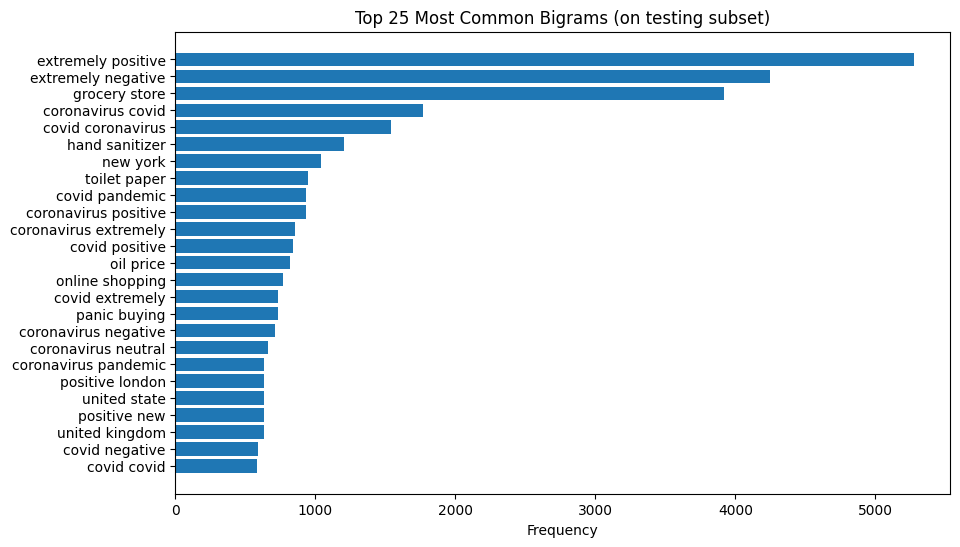

In [21]:
from itertools import chain
from collections import Counter
import matplotlib.pyplot as plt
from nltk.util import bigrams

# Clean train data
clean_train = clean_data(train_df)

# Tokenize cleaned text (split on whitespace)
tokenized_text = clean_train['OriginalTweet'].str.split()

# Flatten list of lists
all_tokens = list(chain.from_iterable(tokenized_text))

unigram_freq = Counter(all_tokens)
top_25_unigrams = unigram_freq.most_common(25)

words, counts = zip(*top_25_unigrams)

plt.figure(figsize=(10, 6))
plt.barh(words[::-1], counts[::-1])
plt.title("Top 25 Most Common Unigrams (on training subset)")
plt.xlabel("Frequency")
plt.show()

# Visu
bigram_tokens = list(bigrams(all_tokens))
bigram_freq = Counter(bigram_tokens)

top_25_bigrams = bigram_freq.most_common(25)

bigrams_words = [' '.join(b) for b, _ in top_25_bigrams]
bigram_counts = [count for _, count in top_25_bigrams]

plt.figure(figsize=(10, 6))
plt.barh(bigrams_words[::-1], bigram_counts[::-1])
plt.title("Top 25 Most Common Bigrams (on testing subset)")
plt.xlabel("Frequency")
plt.show()

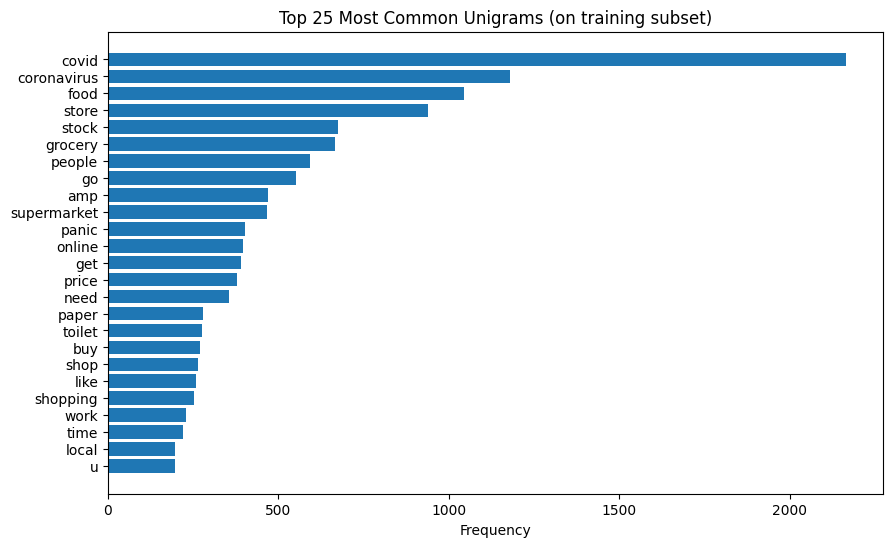

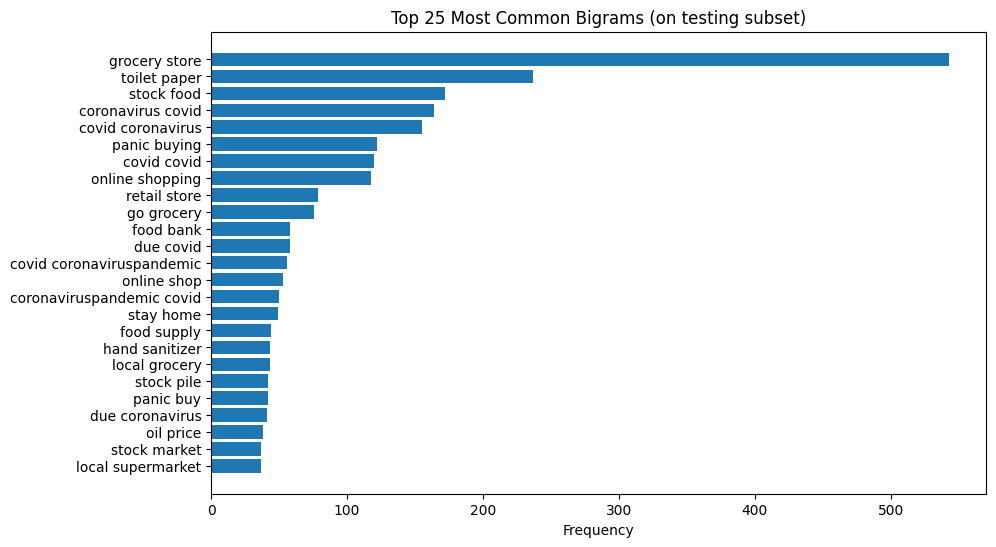

In [22]:
from itertools import chain
from collections import Counter
import matplotlib.pyplot as plt
from nltk.util import bigrams

# Clean train data
clean_test = clean_data(test_df)

# Tokenize cleaned text (split on whitespace)
tokenized_text = clean_test['OriginalTweet'].str.split()

# Flatten list of lists
all_tokens = list(chain.from_iterable(tokenized_text))

unigram_freq = Counter(all_tokens)
top_25_unigrams = unigram_freq.most_common(25)

words, counts = zip(*top_25_unigrams)

plt.figure(figsize=(10, 6))
plt.barh(words[::-1], counts[::-1])
plt.title("Top 25 Most Common Unigrams (on training subset)")
plt.xlabel("Frequency")
plt.show()

# Visu
bigram_tokens = list(bigrams(all_tokens))
bigram_freq = Counter(bigram_tokens)

top_25_bigrams = bigram_freq.most_common(25)

bigrams_words = [' '.join(b) for b, _ in top_25_bigrams]
bigram_counts = [count for _, count in top_25_bigrams]

plt.figure(figsize=(10, 6))
plt.barh(bigrams_words[::-1], bigram_counts[::-1])
plt.title("Top 25 Most Common Bigrams (on testing subset)")
plt.xlabel("Frequency")
plt.show()

In the Sentiment column there are 5 different categories <br>
In Order to reduce the complexity of this target column we will incorporate the extremely <br> 
negative and extremely positive into negative and positive.

In [23]:
def simpler(sent):
    if sent in ['Extremely Positive', 'Positive']:
        return 'Positive'
    elif sent in ['Extremely Negative', 'Negative']:
        return 'Negative'
    else:
        return 'Neutral'


In [24]:
clean_train['Sentiment'] = clean_train['Sentiment'].apply(simpler)
clean_test['Sentiment'] = clean_test['Sentiment'].apply(simpler)

In [25]:
test_df.shape

(2964, 6)

In [26]:
clean_test['Sentiment'].value_counts()

Sentiment
Negative    1260
Positive    1207
Neutral      497
Name: count, dtype: int64

Let 's encode the independent variable: <br>
- Negative --> 0 <br>
- Positive --> 1 <br>
- Neutral --> 2

In [27]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

clean_train['Sentiment'] = le.fit_transform(clean_train['Sentiment'])
clean_test['Sentiment'] = le.fit_transform(clean_test['Sentiment'])

In [28]:
clean_train['Sentiment'].value_counts()

Sentiment
2    14383
0    12012
1     6172
Name: count, dtype: int64

In [29]:
clean_test['Sentiment'].value_counts()

Sentiment
0    1260
2    1207
1     497
Name: count, dtype: int64

# Words Embedding Techniques
Word embedding techniques provide a way to represent words as vectors in a continuous vector space. Word embeddings are numerical representations of words that show semantic similarities and correlations depending on how frequently they appear in a given dataset.
Through the conversion of words into continuous vector spaces, these representations enable machines to interpret and analyze human language with greater efficiency.

There are two major types of word Embeddings:

   - The Frequency Bsed Embeddings (Bag Of Words, TF-IDF)

        - Bag-of-Words (BoW) is a text representation technique that represents a document as an unordered set of words and their respective frequencies.
    It discards the word order and captures the frequency of each word in the document, creating a vector representation.

        - Term Frequency-Inverse Document Frequency, commonly known as TF-IDF, is a numerical statistic that reflects the importance of a word in a document relative to a collection of documents (corpus).

- Prediction Based Embeddings (Word2Vec)

    - Word2Vec is a neural approach for generating word embeddings. It belongs to the family of neural word embedding techniques and specifically falls under
the category of distributed representation models. There are two neural embedding methods for Word2Vec: Continuous Bag of Words (CBOW) and Skip-gram.

        - Continuous Bag of Words (CBOW) is a type of neural network architecture used in the Word2Vec model. The primary objective of CBOW is to predict a target word based on its context, which consists of the surrounding words in a given window.

        - The Skip-Gram model learns distributed representations of words in a continuous vector space. The main objective of Skip-Gram is to predict context words (words surrounding a target word) given a target word. This is the opposite of the Continuous Bag of Words (CBOW) model, where the objective is to predict the target word based on its context

# Let 's Apply Bag Of Words

In [30]:
print(f'The test data shape is: {clean_test.shape}')
print(f'The train data shape is: {clean_train.shape}')

The test data shape is: (2964, 6)
The train data shape is: (32567, 6)


In [31]:
# keep only the OriginalTweet column only
test_tweet = clean_test['OriginalTweet']
train_tweet = clean_train['OriginalTweet']

In [32]:
test_tweet

0                                                     trend new yorkers encounter empty supermarket shelf picture wegmans brooklyn soldout online grocer foodkick maxdelivery coronavirusfearing shopper stock
1                                                                                                          couldnt find hand sanitizer fred meyer turn amazon pack purellcheck coronavirus concern drive price
3               panic buying hit newyork city anxious shopper stock foodampmedical supply healthcare worker become bigapple st confirm coronavirus patient bloomberg stag event qanon qanon qanon election cdc
4       toiletpaper dunnypaper coronavirus coronavirusaustralia coronavirusupdate covid news corvid newsmelb dunnypapergate costco one week everyone buying baby milk powder next everyone buying toilet paper
5                                                                                                     remember last time pay gallon regular gas los angelesprices pump go lo

In [33]:
from sklearn.feature_extraction.text import CountVectorizer
# CountVectorizer : Converts a collection of text documents to a matrix of token counts.
# Create and object for countvectorizer
basicvectorizer = CountVectorizer()
basictrain = basicvectorizer.fit_transform(train_tweet)
print(f'The shape of the train data after the counter vectorization are: {basictrain.shape}\n')

basictest = basicvectorizer.transform(test_tweet)
print(f'The shape of the test data after the transformation are: {basictest.shape}')

The shape of the train data after the counter vectorization are: (32567, 50334)

The shape of the test data after the transformation are: (2964, 50334)


In [34]:
from sklearn.linear_model import LogisticRegression
basicmodel = LogisticRegression()
# Train the logistic regression on the training data
basicmodel = basicmodel.fit(basictrain, clean_train["Sentiment"]) 
# Be carefull on this stage the basic train has only the text data! that why i took df_train['Label'] separate.
basictest = basicvectorizer.transform(test_tweet)
predictions = basicmodel.predict(basictest)
y_true = clean_test["Sentiment"]
y_pred = predictions

In [35]:
# Metrics for this logistic regression is 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix,ConfusionMatrixDisplay

print("Accuracy: ", accuracy_score(y_true, y_pred))
print("Precision: ", precision_score(y_true, y_pred, average='weighted'))
print("Recall: ", recall_score(y_true, y_pred, average='weighted'))
print("F1 Score: ", f1_score(y_true, y_pred, average='weighted'))

Accuracy:  0.6187584345479082
Precision:  0.6127333644540061
Recall:  0.6187584345479082
F1 Score:  0.6102181344511243


The reason why the predictions has so low metrics is that since the the BoW has a serious drawbacks. <br>
Bag Of Word Drawbacks: <br>
- Ordering of the words in the sentences is getting changes. So different sentences have the same meaning. <br>
- Out of vocabulary issue. A new word cannot become a vector easily. <br>
- Semantic meaning is not get capture (we cannot understand which word is more crucial than others). 

# TF-IDF

In [36]:
# keep only the OriginalTweet column only
test_tweet1 = clean_test['OriginalTweet']
train_tweet1 = clean_train['OriginalTweet']

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer

sec_vectorizer = TfidfVectorizer(min_df=0.03, max_df= 0.97,strip_accents= 'unicode') # remove words with frequence lower than 3%.
advancedtrain  = sec_vectorizer.fit_transform(train_tweet1) # x_train
print(f'The shape of the train data after the TFI-DF vectorization are: {advancedtrain.shape}\n')

basictest = sec_vectorizer.transform(test_tweet1)  # x_test
print(f'The shape of the test data after the TFI-DF transformation are: {basictest.shape}')

The shape of the train data after the TFI-DF vectorization are: (32567, 77)

The shape of the test data after the TFI-DF transformation are: (2964, 77)


In [38]:
sec_vectorizer.get_feature_names_out()

array(['amp', 'business', 'buy', 'ca', 'consumer', 'coronavirus', 'covid',
       'crisis', 'day', 'delivery', 'demand', 'due', 'england',
       'extremely', 'food', 'get', 'go', 'good', 'grocery', 'hand',
       'help', 'home', 'impact', 'india', 'keep', 'know', 'like', 'local',
       'london', 'look', 'make', 'many', 'market', 'mask', 'need',
       'negative', 'neutral', 'new', 'oil', 'one', 'online', 'pandemic',
       'panic', 'paper', 'people', 'please', 'positive', 'price',
       'retail', 'sanitizer', 'say', 'see', 'shelf', 'shop', 'shopping',
       'state', 'stay', 'still', 'stock', 'store', 'supermarket',
       'supply', 'take', 'think', 'time', 'today', 'toilet',
       'toiletpaper', 'uk', 'united', 'usa', 'use', 'via', 'week', 'work',
       'worker', 'york'], dtype=object)

In [39]:
advancedtrain.toarray()

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.47214222, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], shape=(32567, 77))

In [42]:
from sklearn.ensemble import (
    RandomForestClassifier, 
    AdaBoostClassifier, 
    GradientBoostingClassifier, 
    AdaBoostClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Models i 'll use to classify the data
models = {
    'Decision Tree':DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boost": GradientBoostingClassifier(),
    "xgboost":XGBClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(), 
    'lightgbm':LGBMClassifier(),
    'LogisticRegression':LogisticRegression()
}   


# Create param grids for every and each of these algorithms
# Decision Tree Hyperparameters
params = {
"Decision Tree" : {  
    'criterion':['gini', 'entropy'],
    'max_depth':[None, 10,20],
    'min_samples_split':[5, 10],
    'min_samples_leaf':[1,4,5]
},

# Random Forest Hyperparameters
"Random Forest" : {
    'n_estimators':[100],
    'max_depth':[2, 5],
    'min_samples_split':[2, 5],
    'min_samples_leaf':[2,10]
    },

# AdaBoost hyperparameters
"AdaBoost" : {
    'n_estimators':[100],
    'learning_rate':[0.05,0.1]
},

# Gradient Boosthyperparameters
"Gradient Boost" :{
    'learning_rate':[0.05,0.1],
    'n_estimators':[100],
    "max_depth": [2, 5]
},

# Xgboost hyperparameters
"xgboost" : {
    'n_estimators':[100],
    'learning_rate':[0.05,0.1],
    'max_depth':[2, 5]
},

# SVM hyperparameters
"SVM":{
    'C': [0.1, 1, 10], # regularization parameter
    'gamma': [1, 0.1]
},
# KNN hyperparameters
'KNN' :{
    'n_neighbors':[3,5]
},

# lightgbm hyperparameters
"lightgbm": {
    "n_estimators": [100],
    "learning_rate": [0.05, 0.1],
    "num_leaves": [31], # this is the default value
    'max_depth':[-1] 
},

# Logistic Regression hyperparameters
"LogisticRegression": {
    "C": [0.1, 1, 10]
}
}

Start tuning the Decision Tree.

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1260
           1       0.17      1.00      0.29       497
           2       0.82      0.01      0.03      1207

    accuracy                           0.17      2964
   macro avg       0.33      0.34      0.11      2964
weighted avg       0.36      0.17      0.06      2964



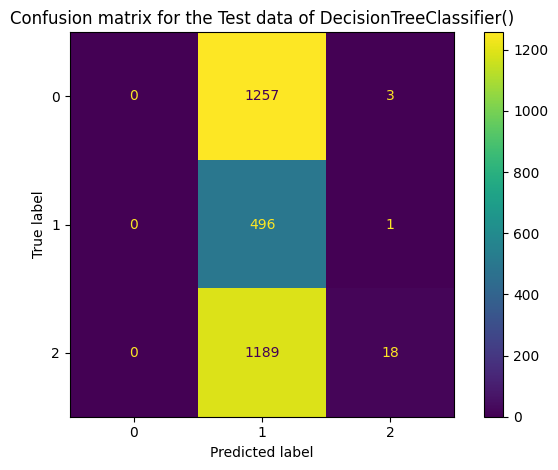

Start tuning the Random Forest.

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.13      0.23      1260
           1       0.00      0.00      0.00       497
           2       0.43      0.98      0.59      1207

    accuracy                           0.45      2964
   macro avg       0.42      0.37      0.28      2964
weighted avg       0.53      0.45      0.34      2964



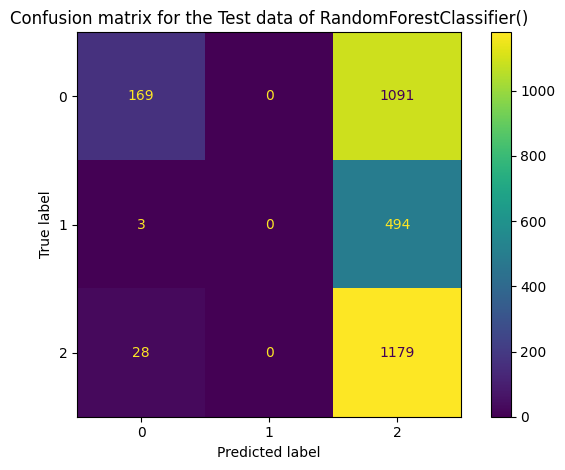

Start tuning the AdaBoost.

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1260
           1       0.00      0.00      0.00       497
           2       0.41      1.00      0.58      1207

    accuracy                           0.41      2964
   macro avg       0.14      0.33      0.19      2964
weighted avg       0.17      0.41      0.24      2964



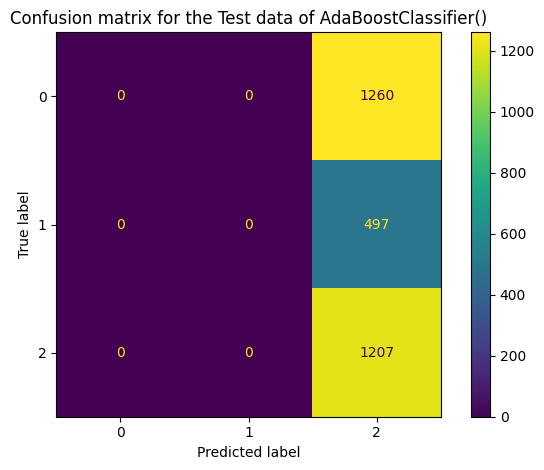

Start tuning the Gradient Boost.

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1260
           1       0.00      0.00      0.00       497
           2       0.41      1.00      0.58      1207

    accuracy                           0.41      2964
   macro avg       0.14      0.33      0.19      2964
weighted avg       0.17      0.41      0.24      2964



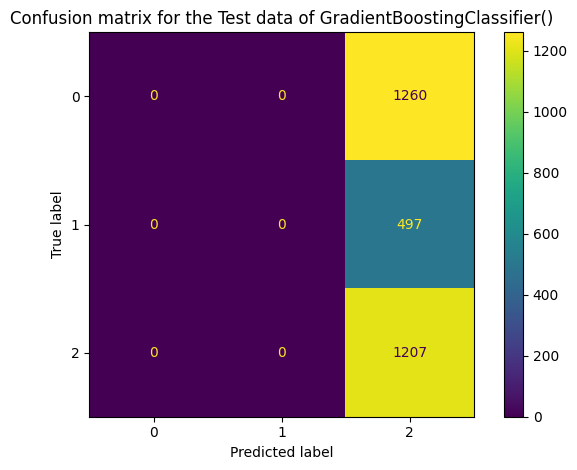

Start tuning the xgboost.

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1260
           1       0.00      0.00      0.00       497
           2       0.41      1.00      0.58      1207

    accuracy                           0.41      2964
   macro avg       0.14      0.33      0.19      2964
weighted avg       0.17      0.41      0.24      2964



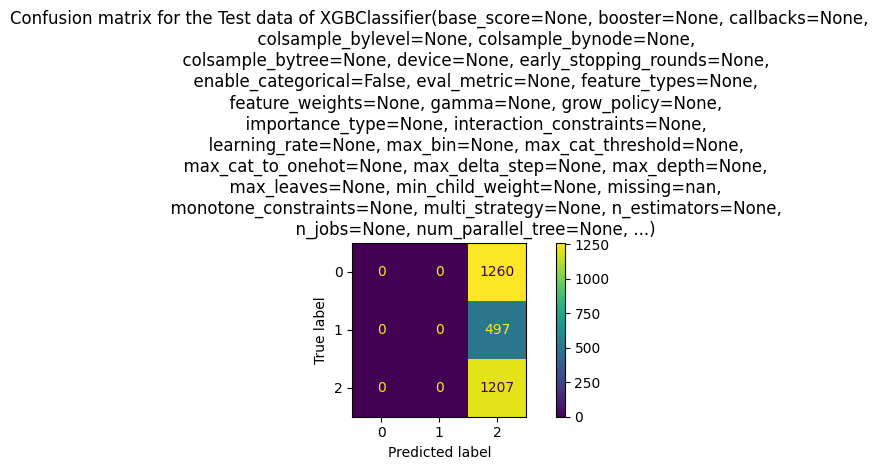

Start tuning the SVM.

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.12      0.20      1260
           1       0.00      0.00      0.00       497
           2       0.42      0.98      0.59      1207

    accuracy                           0.45      2964
   macro avg       0.42      0.37      0.27      2964
weighted avg       0.53      0.45      0.33      2964



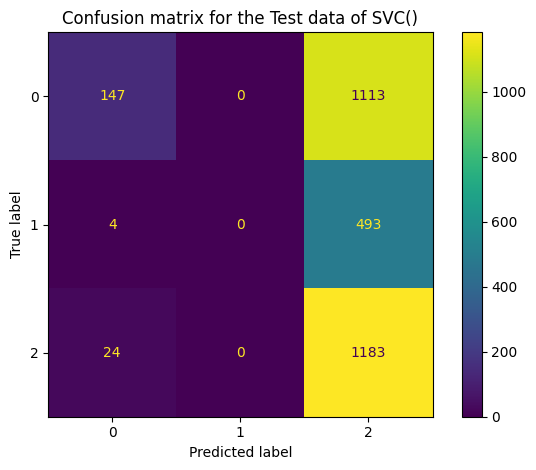

Start tuning the KNN.

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.55      0.53      1260
           1       0.29      0.12      0.17       497
           2       0.49      0.58      0.53      1207

    accuracy                           0.49      2964
   macro avg       0.43      0.41      0.41      2964
weighted avg       0.47      0.49      0.47      2964



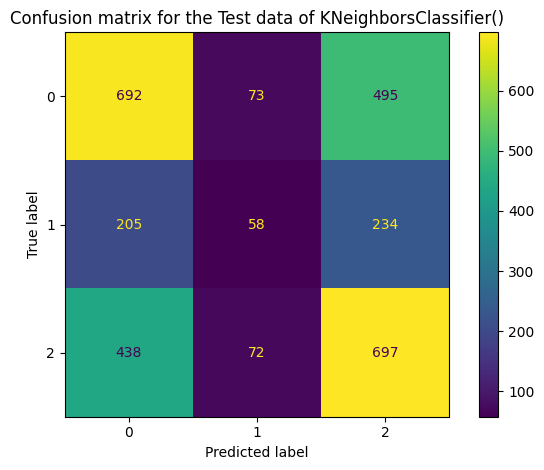

Start tuning the lightgbm.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008652 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 19627
[LightGBM] [Info] Number of data points in the train set: 32567, number of used features: 77
[LightGBM] [Info] Start training from score -0.997393
[LightGBM] [Info] Start training from score -1.663277
[LightGBM] [Info] Start training from score -0.817253
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.13      0.22      1260
           1       0.00      0.00      0.00       497
           2       0.42      0.96      0.59  

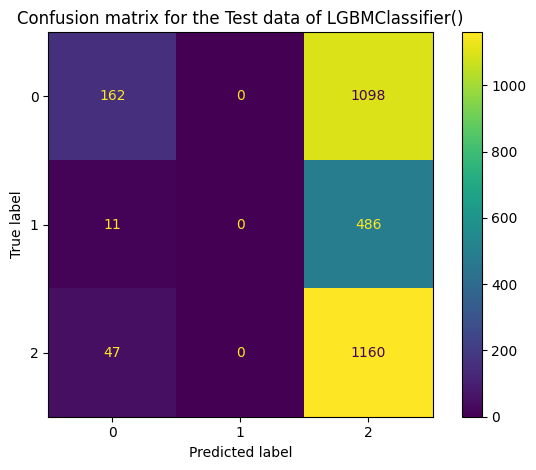

Start tuning the LogisticRegression.

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.28      0.41      1260
           1       0.00      0.00      0.00       497
           2       0.45      0.93      0.61      1207

    accuracy                           0.50      2964
   macro avg       0.40      0.40      0.34      2964
weighted avg       0.50      0.50      0.42      2964



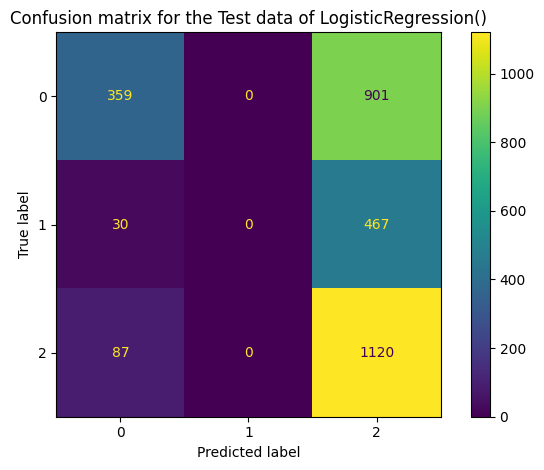

In [43]:
from sklearn.model_selection import GridSearchCV
import warnings
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix,ConfusionMatrixDisplay, roc_auc_score,roc_curve,auc
warnings.filterwarnings("ignore")

# Empty dictionary to save all of the hyperparameter tuning results for each parameter.
result = {}

scoring = {'f1':'f1','accuracy': 'accuracy'}
for model_name, model in models.items():
    print(f"Start tuning the {model_name}.") # only for debugging purposes
    clf = model  # get the model
    hype = params[model_name] # get the hyperparameters for hyperparameter tuning
    
    # grid search cv to get the best combination of hyperparameters
    grid  = GridSearchCV(clf,  
                    hype, 
                    scoring='f1', 
                    n_jobs = -1, # To use the whole cpu and get faster results.
                    cv=5).fit(advancedtrain, clean_train["Sentiment"])
    
    # update the result dict
    result[model_name] = {
        "best_params": grid.best_params_, # Parameter setting that gave the best results on the hold out data.
        "best_f1": grid.best_score_,   # Mean cross-validated score of the best_estimator. 
        "best_model": grid.best_estimator_ # the best set of parameters
    }
    
    # print(f'\nThe best cross validation score (f1) for the {model_name} is : {grid.best_score_}\n\n')
    best_model = grid.best_estimator_ # use the best estimetor to predict on the testing set 

    # ---- Test set evaluation ----
    y_pred = best_model.predict(basictest)

    print("\nClassification Report:")
    print(classification_report(clean_test['Sentiment'], y_pred))

    # # ---- ROC / AUC (only if supported) ---- (For example SVM)
    # if hasattr(best_model, "predict_proba"):
    #     y_pred_prob = best_model.predict_proba(basictest)[:, 1]

    #     fpr, tpr, _ = roc_curve(clean_test['Sentiment'], y_pred_prob)
    #     roc_auc = auc(fpr, tpr)

    #     plt.figure()
    #     plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')
    #     plt.plot([0, 1], [0, 1], 'r--', label='Random Guess')
    #     plt.xlabel('False Positive Rate')
    #     plt.ylabel('True Positive Rate')
    #     plt.title(f'ROC Curve – {model_name}')
    #     plt.legend()
    #     plt.tight_layout()
    #     plt.show()
        
    # Plot Confusion matrix on ax[1]
    cm = confusion_matrix(clean_test['Sentiment'], y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f'Confusion matrix for the Test data of {model}')
    plt.tight_layout()
    plt.show()

# Deep Learning Training Models (Neural Approach)
Word2Vec (developed by google researchers) is a neural approach for generating word embeddings. It belongs to the family of neural word <br> embedding techniques and specifically falls under the category of distributed representation models.
- Continuous Bag of Words (CBOW) is a type of neural network architecture used in the Word2Vec model. The primary objective of CBOW is to predict  <br> a target word based on its context, which consists of the surrounding words in a given window.
- The Skip-Gram model learns distributed representations of words in a continuous vector space. The main objective of Skip-Gram is to predict <br> context words (words surrounding a target word) given a target word. This is the opposite of the Continuous Bag of Words (CBOW) model.

# CBOW